<p style="color:blue;">UNIVERSIDAD DE SAN CARLOS DE GUATEMALA</p>
<p style="color:blue;">FACULTAD DE INGENIERÍA</p>
<p style="color:blue;">INGENIERÍA EN CIENCIAS Y SISTEMAS</p>
<p style="color:blue;">SEMINARIO DE SISTEMAS 2</p>
<p style="color:blue;">SECCIÓN A</p>
<p style="color:blue;">INGRID LORENA GARCIA YANTUCHE</p>
<p style="color:blue;">CARNÉ: 201700399</p>
<p style="color:blue;">PRÁCTICA 2</p>

Instalación de las librerias necesarias a utilizar en el entorno de trabajo, se ejecuto el siguiente comando:
-  pip install pandas numpy matplotlib seaborn nltk

Posteriormente se realizo la importación de las librerías a utilizar.

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Carga de datos  .csv

Se realizó la carga del archivo "datos.csv" de Coursera usando la librería Pandas
- > pd.read_csv('datos.csv')

In [71]:
df = pd.read_csv('datos.csv')
total_filas = len(df)
print(f'El archivo CSV contiene {total_filas} filas.')

El archivo CSV contiene 9595 filas.


# Limpieza de datos

De los datos cargados se procedió a realizar una limpieza de datos como primer paso se realizó la eliminación de valores nulos o vacios.
- > isnull().sum()
- > dropna(inplace=True)

In [72]:
df.isnull().sum()
df.dropna(inplace=True)
print('Filas: ' ,len(df))

Filas:  3517


Eliminación de datos duplicados
- > drop_duplicates()
- > fillna(0)

In [73]:
df = df.drop_duplicates()
df = df.fillna(0)
print('Filas: ' ,len(df))

Filas:  3227


Verificar que la columna 'Rating' sea de tipo numérico
- > pd.to_numeric()

In [ ]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

Convertir la columna 'Duration' a horas: de los datos cargados se observó que la columna 'Duration' tenia este formato
- Approx. 44 hours to complete
- 2 months at 10 hours a week

Para la realización de un mejor análisis se decidió trabajar en horas 

In [76]:
def durationHoras(duration):
    duration = str(duration)
    
    if "hours" and "week" not in duration:
        hours = re.findall(r'\d+', duration)  
        if hours:
            return int(hours[0]) 
        else:
            return 0
        
    # 2 months at 10 hours a week           
    elif "months" in duration and "week" in duration:
        months_and_hours = re.findall(r'\d+', duration)
        print(months_and_hours)
        if len(months_and_hours) == 2:
            months = int(months_and_hours[0])  
            hours_per_week = int(months_and_hours[1])  
            total_weeks = months * 4 
            return total_weeks * hours_per_week 
        else:
            return 0 
    
    return 0

df['Duration'] = df['Duration'].apply(durationHoras)

#df.to_csv('datos2.csv', index=False)
df[['Duration']].head()

,Duration
4,11
5,5
13,10
21,21
28,52


# Cálculo del promedio de calificaciones por curso.

Para el calculo del promedio de calificaciones por cada curso se utilizó el método:
- > df.mean()

C:\Users\logas\AppData\Local\Temp\ipykernel_19276\4092907158.py:23: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\4092907158.py:23: UserWarning: Glyph 30990 (\N{CJK UNIFIED IDEOGRAPH-790E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\4092907158.py:23: UserWarning: Glyph 30693 (\N{CJK UNIFIED IDEOGRAPH-77E5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\4092907158.py:23: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\4092907158.py:23: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\4092907158.py:23: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(

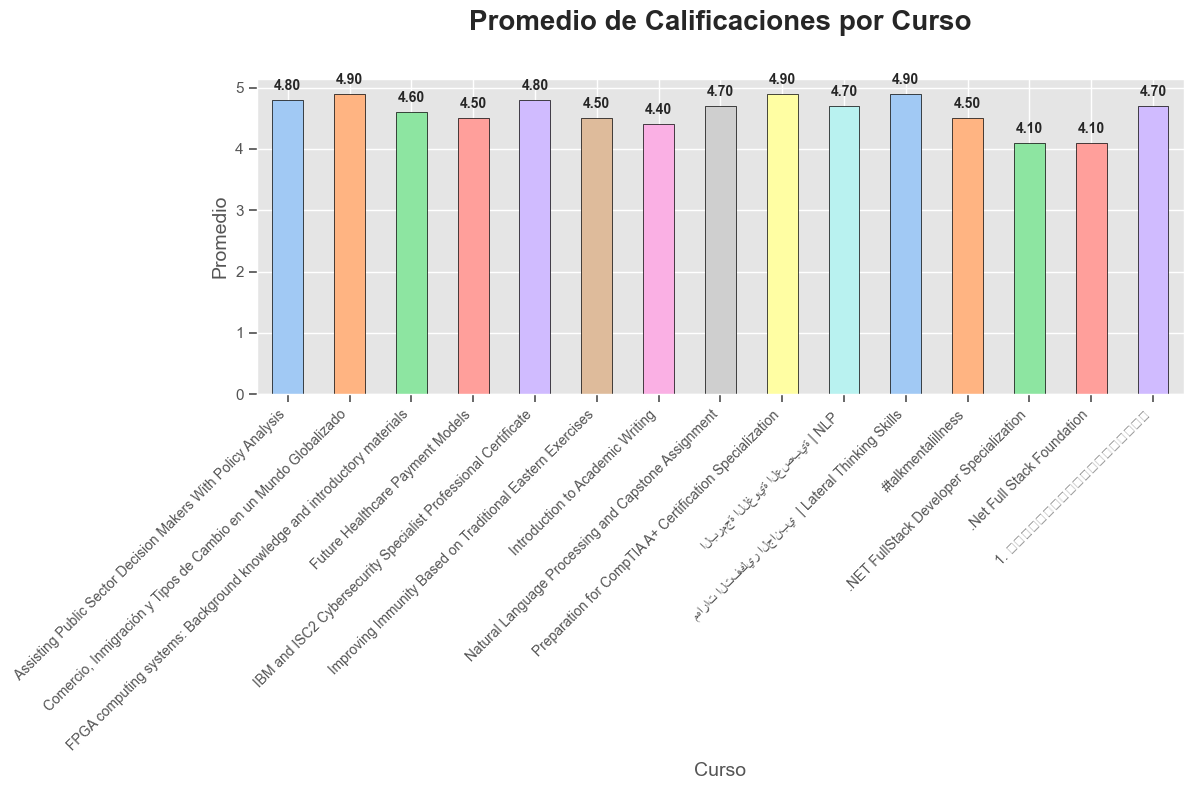

In [190]:
plt.style.use('ggplot')

promedio = df.groupby('Course Title')['Rating'].mean()

colors = sns.color_palette("pastel", 15)
plt.figure(figsize=(12, 8))
bars = promedio.head(15).plot(kind='bar', color=colors, edgecolor='black')

# Etiquetas de gráfica
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.2f}', 
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='center', 
                  xytext=(0, 10), 
                  textcoords='offset points', 
                  fontsize=10, fontweight='bold')

plt.title('Promedio de Calificaciones por Curso', fontsize=20, fontweight='bold', pad=35)
plt.ylabel('Promedio', fontsize=14)
plt.xlabel('Curso', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

In [108]:
print(promedio.head(15))

Course Title
 Assisting Public Sector Decision Makers With Policy Analysis               4.8
 Comercio, Inmigración y Tipos de Cambio en un Mundo Globalizado            4.9
 FPGA computing systems: Background knowledge and introductory materials    4.6
 Future Healthcare Payment Models                                           4.5
 IBM and ISC2 Cybersecurity Specialist Professional Certificate             4.8
 Improving Immunity Based on Traditional Eastern Exercises                  4.5
 Introduction to Academic Writing                                           4.4
 Natural Language Processing and Capstone Assignment                        4.7
 Preparation for CompTIA A+ Certification Specialization                    4.9
 البرمجة اللغوية العصبية | NLP                                              4.7
 مهارات التفكير الجانبي  | Lateral Thinking Skills                          4.9
#talkmentalillness                                                          4.5
.NET FullStack Developer Sp

<div style="text-align: justify;">

> <p style="color:orange;"> De los resultados obtenidos, se puede observar que el rating de los primeros 15 cursos se encuentra entre 4.1 y 4.9. Esto indica un interés significativo en estos cursos, sugiriendo que los temas tratados son particularmente atractivos y útiles para los usuarios.</p>
</div>

#  Calcular los cursos con mayor y menor rating.

Para realizar el cálculo de los cursos con mayor rating se utilizó la siguiente función de Pandas:
- > nlargest()

En este caso, se solicitó obtener los 10 cursos con el rating más alto, lo que nos permite centrarnos en los cursos que están sobresaliendo en calidad y satisfacción del usuario.

C:\Users\logas\AppData\Local\Temp\ipykernel_19276\880606374.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Course Title', y='Rating', data=max, palette='coolwarm', edgecolor='black')


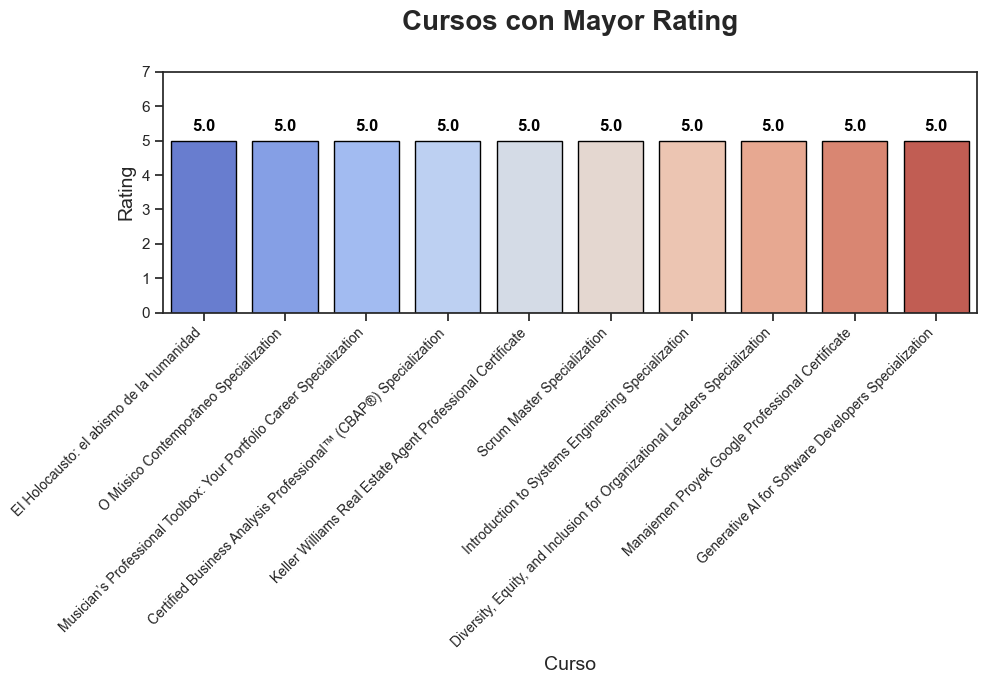

In [189]:
max = df.nlargest(10, 'Rating')

plt.figure(figsize=(10, 7))
sns.set(style="ticks")

bars = sns.barplot(x='Course Title', y='Rating', data=max, palette='coolwarm', edgecolor='black')

# Etiquetas de gráfica
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.1f}', 
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom', 
                  xytext=(0, 5), 
                  textcoords='offset points', 
                  fontsize=12, fontweight='bold', color='black')

plt.title('Cursos con Mayor Rating', fontsize=20, fontweight='bold',pad=30)
plt.ylabel('Rating', fontsize=14)
plt.xlabel('Curso', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0, 7) 

plt.tight_layout()
plt.show()

Para realizar el cálculo de los cursos con menor rating se utilizó la siguiente función de Pandas:
- > nsmallest()

En este caso, se solicitó obtener los 10 cursos con el menor rating, lo que nos permite centrarnos en los cursos que requieren mejoras.

C:\Users\logas\AppData\Local\Temp\ipykernel_19276\2006681885.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Course Title', y='Rating', data=min, palette='pastel', edgecolor='black')


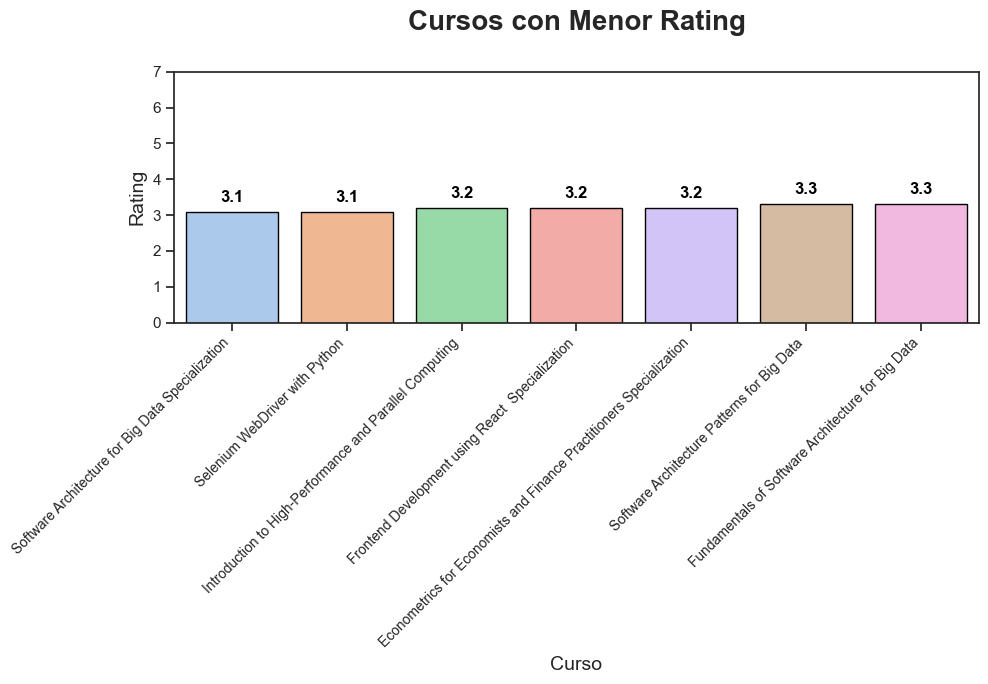

In [191]:
min = df.nsmallest(10, 'Rating')

plt.figure(figsize=(10, 7))
sns.set(style="ticks")  

bars = sns.barplot(x='Course Title', y='Rating', data=min, palette='pastel', edgecolor='black')

# Etiquetas de gráfica
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.1f}', 
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom', 
                  xytext=(0, 5), 
                  textcoords='offset points', 
                  fontsize=12, fontweight='bold', color='black')

plt.title('Cursos con Menor Rating', fontsize=20, fontweight='bold', pad=30)
plt.ylabel('Rating', fontsize=14)
plt.xlabel('Curso', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0, 7) 

plt.tight_layout()
plt.show()

<Figure size 2000x800 with 0 Axes>

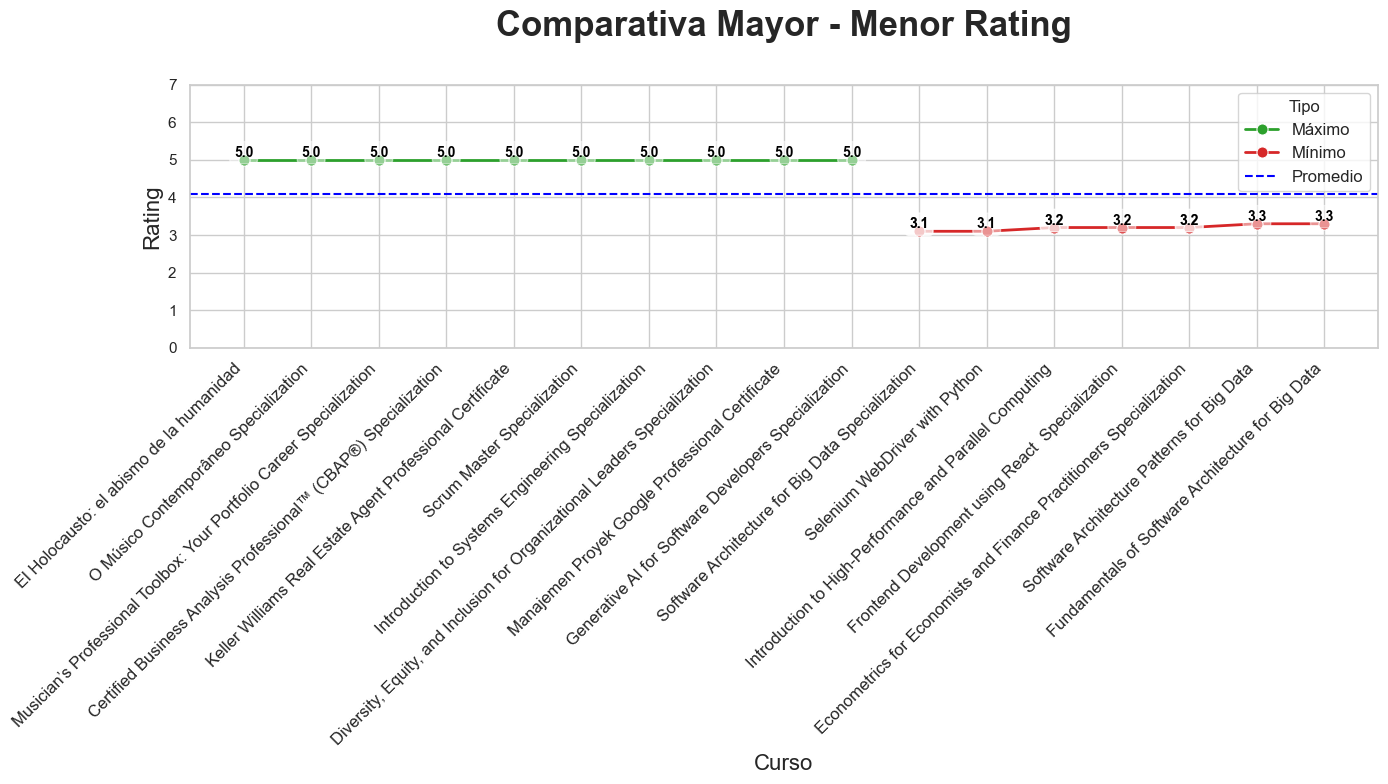

In [203]:
plt.figure(figsize=(20, 8))

combined = pd.concat([max, min])
combined['Type'] = ['Máximo'] * len(max) + ['Mínimo'] * len(min)

plt.figure(figsize=(14, 8))

sns.set(style='whitegrid')

sns.lineplot(x='Course Title', y='Rating', data=combined, hue='Type', 
             marker='o', palette=['#2ca02c', '#d62728'], linewidth=2, markersize=8)

for index, row in combined.iterrows():
    plt.text(row['Course Title'], row['Rating'], f'{row["Rating"]:.1f}', 
             color='black', ha='center', va='bottom', fontsize=10, fontweight='bold', 
             bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.3'))

plt.axhline(y=combined['Rating'].mean(), color='blue', linestyle='--', label='Promedio', linewidth=1.5)

plt.title('Comparativa Mayor - Menor Rating', fontsize=25, fontweight='bold',pad=35)
plt.ylabel('Rating', fontsize=16)
plt.xlabel('Curso', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylim(0, 7)  

plt.legend(title='Tipo', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

<div style="text-align: justify;">
 
 > <p style="color:orange;">Los resultados obtenidos muestran que varios cursos tienen un rating alto que se encuentra valorados con una puntuación de 5, lo que indica que son útiles y de gran ayuda para los usuarios. Esto sugiere que los cursos más valorados cumplen con las expectativas y necesidades de los participantes. Por otro lado, los cursos con las calificaciones más bajas tienen ratings que oscilan entre 3.1 y 3.3, siendo estos los primeros siete en la lista. Esta tendencia resalta la necesidad de identificar y abordar los aspectos que requieren mejora en estos cursos. Es esencial evaluar los comentarios de los usuarios para implementar cambios que optimicen la experiencia de aprendizaje.</p>
</div>

# Porcentaje de cursos con horario flexible en relación con el total de cursos en el conjunto de datos.

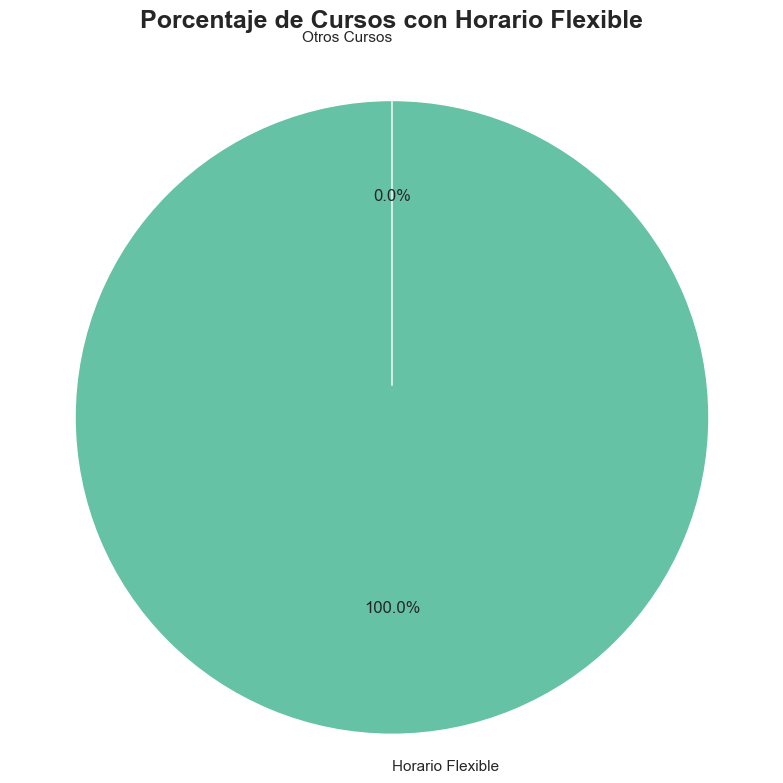

In [206]:
cursos_horario_flexible = df[df['Schedule'] == 'Flexible schedule']

# Calcular el total de cursos
total_cursos = len(df)

# Calcular el total de cursos con horario flexible
total_cursos_horario_flexible = len(cursos_horario_flexible)

# Calcular el porcentaje
porcentaje_horario_flexible = (total_cursos_horario_flexible / total_cursos) * 100
porcentaje_horario_flexible_redondeado = round(porcentaje_horario_flexible, 2)

# Datos para el gráfico
labels = ['Horario Flexible', 'Otros Cursos']
sizes = [porcentaje_horario_flexible_redondeado, 100 - porcentaje_horario_flexible_redondeado]
colors = ['#66c2a5', '#fc8d62']  # Colores personalizados

# Crear gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0))  # Explode el primer segmento
plt.title('Porcentaje de Cursos con Horario Flexible', fontsize=18, fontweight='bold')
plt.axis('equal')  # Asegura que el gráfico sea un círculo

# Mostrar el gráfico
plt.tight_layout()
plt.show()

<div style="text-align: justify;">
 
 > <p style="color:orange;">Los resultados obtenidos muestran que varios cursos tienen un rating alto que se encuentra valorados con una puntuación de 5, lo que indica que son útiles y de gran ayuda para los usuarios. Esto sugiere que los cursos más valorados cumplen con las expectativas y necesidades de los participantes. Por otro lado, los cursos con las calificaciones más bajas tienen ratings que oscilan entre 3.1 y 3.3, siendo estos los primeros siete en la lista. Esta tendencia resalta la necesidad de identificar y abordar los aspectos que requieren mejora en estos cursos. Es esencial evaluar los comentarios de los usuarios para implementar cambios que optimicen la experiencia de aprendizaje.</p>
</div>

# NLKT
# Análisis de texto en el archivo .txt 

In [64]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, SnowballStemmer, PorterStemmer
from nltk.probability import FreqDist
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk import ne_chunk, pos_tag
from nltk.tree import Tree

# Descargar recursos necesarios
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to C:\Users\logas/nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\logas/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\logas/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\logas/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\logas/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\logas/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to C:\Users\logas/nltk_data...
[nltk_data]   Package words is already 

True

# Cargar el archivo .txt

In [61]:
with open('Coursera Comments.txt', 'r', encoding='utf-8') as file:
    texto = file.read()

# Tokenización

La tokenización consiste en dividir un texto en sus componentes más pequeños: palabras o signos de puntuación. En este caso, word_tokenize toma el contenido del archivo .txt y lo convierte en una lista de tokens (palabras o símbolos). Esto es útil para realizar análisis de texto posteriores como frecuencia de palabras o eliminación de palabras vacías.

In [62]:
#
tokens  = word_tokenize(texto)
print(tokens[:10])

['Abril', 'Vargas', 'Pérez', '3', 'opiniones', 'PT', 'Valorada', 'con', '5', 'estrellas']


# Elmininación de palabras vacías

Las palabras vacías (stopwords) son palabras comunes como "the", "is", "and", que no aportan mucho significado en el análisis de texto. Este código elimina esas palabras del conjunto de tokens para enfocarse solo en palabras más relevantes.

In [52]:
stop_words = set(stopwords.words('spanish'))
tokens_sin_stopwords = [palabra for palabra in tokens if palabra.lower() not in stop_words]
print(tokens_sin_stopwords[:15])

['Abril', 'Vargas', 'Pérez', '3', 'opiniones', 'PT', 'Valorada', '5', 'estrellas', '5', '21', 'ago', '2024', 'Escandalizada', 'confundida']


#  Lematización y Stemming

- Lematización: Reduce las palabras a su forma base o raíz léxica (por ejemplo, "am", "are", "is" se convierten en "be").
- Stemming: Corta los sufijos de las palabras para reducirlas a su raíz morfológica (por ejemplo, "playing", "played" se reducen a "play"). Ambas técnicas ayudan a reducir la variabilidad de las palabras, permitiendo un análisis más preciso.

In [53]:
lemmatizer = WordNetLemmatizer()
stemmer = SnowballStemmer('spanish')

# Lematización
tokens_lematizados = [lemmatizer.lemmatize(palabra) for palabra in tokens_sin_stopwords]
print(tokens_lematizados[:10]) 

# Stemming
tokens_stemming = [stemmer.stem(palabra) for palabra in tokens_sin_stopwords]
print(tokens_stemming [:10])


['Abril', 'Vargas', 'Pérez', '3', 'opiniones', 'PT', 'Valorada', '5', 'estrellas', '5']
['abril', 'varg', 'perez', '3', 'opinion', 'pt', 'valor', '5', 'estrell', '5']


#  Frecuencia de palabras

Se calcula la frecuencia con la que aparecen las palabras en el texto filtrado (sin palabras vacías). FreqDist genera un diccionario con las palabras y su frecuencia de aparición. Luego, se grafica las 10 palabras más comunes utilizando un gráfico de barras.

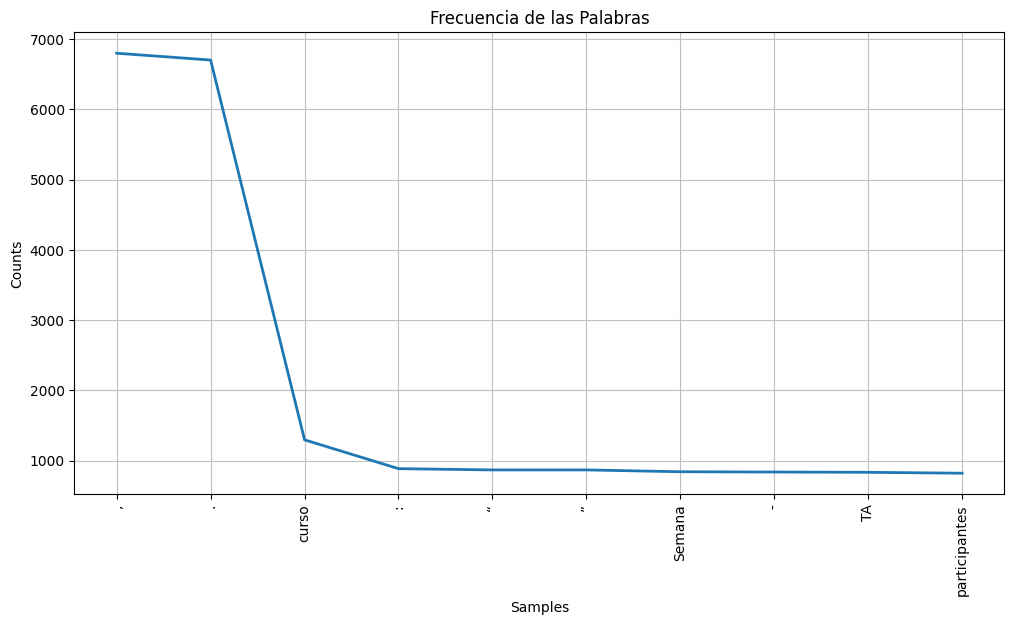

In [56]:
fdist = FreqDist(tokens_sin_stopwords)

plt.figure(figsize=(12, 6))
fdist.plot(10, cumulative=False)
plt.title('Frecuencia de las Palabras')
plt.show()

#  Analisis de sentimientos

El análisis de sentimientos mide la carga emocional de un texto. Utiliza el modelo VADER para asignar puntajes de polaridad a un texto, indicando si el sentimiento es positivo, negativo o neutral. Los resultados se muestran en forma de un diccionario con puntuaciones de los diferentes aspectos del sentimiento.

In [63]:
sia = SentimentIntensityAnalyzer()
sentimiento = sia.polarity_scores(texto)

print(sentimiento)

{'neg': 0.035, 'neu': 0.954, 'pos': 0.011, 'compound': -1.0}


# Reconocimiento de entidades nombradas

El Reconocimiento de Entidades Nombradas (NER) identifica entidades como nombres de personas, organizaciones, lugares, etc. Este código utiliza la biblioteca spaCy para procesar el texto y extraer entidades con sus respectivas categorías. Es útil para comprender qué entidades son mencionadas frecuentemente en un texto.

In [67]:
tags = pos_tag(tokens_sin_stopwords) 
entities = ne_chunk(tags, binary=False)

#  Extraer entidades

In [68]:
def get_entities(tree):
    entities = []
    for subtree in tree:
        if isinstance(subtree, Tree):
            entity_name = " ".join([token for token, pos in subtree.leaves()])
            entity_type = subtree.label()
            entities.append((entity_name, entity_type))
    return entities

# Extraer entidades del árbol NER
named_entities = get_entities(entities)
for entity in named_entities:
    print(entity)

('Abril', 'PERSON')
('Vargas Pérez', 'PERSON')
('PT', 'ORGANIZATION')
('Meta', 'ORGANIZATION')
('Coursera Plus', 'PERSON')
('Duré', 'PERSON')
('Quizás', 'PERSON')
('Velocidad', 'GPE')
('Fecha', 'PERSON')
('Fecha', 'PERSON')
('ESTAFADORES', 'ORGANIZATION')
('Coursera Plus', 'PERSON')
('Fecha', 'PERSON')
('ESTAFADORES', 'ORGANIZATION')
('ESTAFADORES', 'ORGANIZATION')
('Mismo', 'PERSON')
('Fecha', 'PERSON')
('Maria Eugenia Simancas Soriano', 'PERSON')
('US', 'ORGANIZATION')
('Cuidado', 'PERSON')
('Además', 'PERSON')
('Fecha', 'PERSON')
('US', 'ORGANIZATION')
('Creo', 'PERSON')
('Courser Learner', 'PERSON')
('Curso', 'PERSON')
('Universidad Andes', 'ORGANIZATION')
('Fecha', 'PERSON')
('Fecha', 'PERSON')
('Jeanpierre Nuñez', 'PERSON')
('Microsoft', 'ORGANIZATION')
('Porqueria', 'GPE')
('Fecha', 'PERSON')
('Cristian', 'GPE')
('Pésimo', 'PERSON')
('Fecha', 'PERSON')
('Determina', 'GPE')
('Maha Visnu Da Silva', 'PERSON')
('CL', 'ORGANIZATION')
('Fecha', 'PERSON')
('Fecha', 'PERSON')
('Andres H

# Gráficos